# NOTEBOOK 06 — TRUSTWORTHY ML: SHAP, UNCERTAINTY & OOD DETECTION

This notebook extends the final band-gap model with three research-grade components: model explanation, uncertainty estimation, and an applicability-domain check. These are designed to answer not only **what** the model predicts, but also **why** and **when we should trust it**.


In [24]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

# ============================================================
# Project configuration
# ============================================================

ROOT = Path(r"F:\Quantum-materials")

DATA_FILE = ROOT / "data" / "enhanced_material_descriptors.csv"
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

# Make project modules importable
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Check everything
print("Project root:", ROOT)
print("Data file:", DATA_FILE)
print("Data exists:", DATA_FILE.exists())
print("src exists:", (ROOT / "src").exists())
print("results exists:", RESULTS.exists())

RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# Project imports
from src.models import create_model_pipeline
from src.preprocessing import FEATURE_COLUMNS

print("Imports successful!")
print("Number of features:", len(FEATURE_COLUMNS))

Project root: F:\Quantum-materials
Data file: F:\Quantum-materials\data\enhanced_material_descriptors.csv
Data exists: True
src exists: True
results exists: True
Imports successful!
Number of features: 25


In [25]:
df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)

X = df[FEATURE_COLUMNS].copy()
y = pd.to_numeric(df["target_bandgap"], errors="coerce")

valid = y.notna()

print("Valid rows:", valid.sum())
print("Number of features:", len(FEATURE_COLUMNS))

Dataset shape: (93902, 26)
Valid rows: 93902
Number of features: 25


In [27]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# ============================================================
# FIXED PROJECT ROOT
# ============================================================

ROOT = Path(r"F:\Quantum-materials")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models import create_model_pipeline
from src.preprocessing import FEATURE_COLUMNS, NUMERIC_FEATURES

# ============================================================
# FILE PATHS
# ============================================================

DATA_FILE = ROOT / "data" / "enhanced_material_descriptors.csv"

RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"

RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

# Check path BEFORE reading
print("Project root:", ROOT)
print("Data file:", DATA_FILE)
print("Data exists:", DATA_FILE.exists())

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

X = df[FEATURE_COLUMNS].copy()

y = pd.to_numeric(
    df["target_bandgap"],
    errors="coerce"
)

valid = y.notna()

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

print(f"Materials: {len(X):,}")
print(f"Features: {len(FEATURE_COLUMNS)}")

Project root: F:\Quantum-materials
Data file: F:\Quantum-materials\data\enhanced_material_descriptors.csv
Data exists: True
Materials: 93,902
Features: 25


In [30]:
# Cell 27 — Create evaluation split and final tuned model

from sklearn.model_selection import train_test_split

# Stratified split based on zero/non-zero band gap
y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class,
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print()

print("Training zero-gap materials:", int((y_train == 0).sum()))
print("Training non-zero-gap materials:", int((y_train > 0).sum()))
print()

print("Test zero-gap materials:", int((y_test == 0).sum()))
print("Test non-zero-gap materials:", int((y_test > 0).sum()))

# Create the final tuned Random Forest pipeline
pipeline = create_model_pipeline()

print()
print("Model pipeline created successfully.")
print(pipeline)

Training samples: 75121
Test samples: 18781

Training zero-gap materials: 53649
Training non-zero-gap materials: 21472

Test zero-gap materials: 13413
Test non-zero-gap materials: 5368

Model pipeline created successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['num_elements',
                                                   'total_atoms',
                                                   'mean_atomic_number',
                                                   'min_atomic_number',
                                                   'max_atomic_number',
                                                   'mean_atomic_mass',
                                                   'min_atomic_mass',
              

## 1. Recreate the final evaluation split

The untouched test set remains separate from the uncertainty calibration and interpretation work. This prevents the advanced analysis from silently changing the reported test performance.


In [31]:
y_class = (y > 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y_class
)

model = create_model_pipeline()
model.fit(X_train, y_train)
test_pred = model.predict(X_test)

print(f'MAE  : {mean_absolute_error(y_test, test_pred):.4f} eV')
print(f'RMSE : {mean_squared_error(y_test, test_pred) ** 0.5:.4f} eV')
print(f'R²   : {r2_score(y_test, test_pred):.4f}')


MAE  : 0.2381 eV
RMSE : 0.5559 eV
R²   : 0.8195


## 2. Random-Forest uncertainty proxy

The spread of individual tree predictions is used as a **model-dispersion proxy**. It is useful for ranking confidence, but it is **not a calibrated prediction interval**.


In [32]:
preprocessor = model.named_steps['preprocessor']
forest = model.named_steps['model']
X_test_transformed = preprocessor.transform(X_test)

tree_predictions = np.vstack([
    tree.predict(X_test_transformed) for tree in forest.estimators_
])
rf_uncertainty = tree_predictions.std(axis=0)

uncertainty_df = pd.DataFrame({
    'actual_bandgap': y_test.to_numpy(),
    'predicted_bandgap': test_pred,
    'uncertainty_proxy': rf_uncertainty,
})
uncertainty_df['absolute_error'] = (
    uncertainty_df['actual_bandgap'] - uncertainty_df['predicted_bandgap']
).abs()

print(uncertainty_df.describe())
print('\nMean absolute error by uncertainty quartile:')
uncertainty_df['uncertainty_bin'] = pd.qcut(
    uncertainty_df['uncertainty_proxy'], q=4, duplicates='drop'
)
print(uncertainty_df.groupby('uncertainty_bin', observed=True)['absolute_error'].mean())


       actual_bandgap  predicted_bandgap  uncertainty_proxy  absolute_error
count    18781.000000       18781.000000       18781.000000    18781.000000
mean         0.578223           0.583815           0.363026        0.238135
std          1.308571           1.164796           0.503887        0.502313
min          0.000000           0.000000           0.000000        0.000000
25%          0.000000           0.000000           0.000000        0.000000
50%          0.000000           0.024435           0.105938        0.019529
75%          0.228000           0.574540           0.589519        0.247751
max         18.098000          17.915443           3.427371        7.978410

Mean absolute error by uncertainty quartile:
uncertainty_bin
(-0.001, 0.106]    0.007484
(0.106, 0.59]      0.170010
(0.59, 3.427]      0.767611
Name: absolute_error, dtype: float64


## 3. Split-conformal prediction intervals

A calibration subset is used to estimate residual quantiles. The resulting interval is a statistical calibration layer under the usual exchangeability assumptions; it should not be interpreted as a physical uncertainty bar.


In [33]:
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.20, random_state=123, stratify=(y_train > 0).astype(int)
)

conformal_model = create_model_pipeline()
conformal_model.fit(X_fit, y_fit)
cal_pred = conformal_model.predict(X_cal)
cal_abs_residual = np.abs(y_cal.to_numpy() - cal_pred)

alpha = 0.10
q_level = min(1.0, np.ceil((len(cal_abs_residual) + 1) * (1 - alpha)) / len(cal_abs_residual))
q = np.quantile(cal_abs_residual, q_level, method='higher')

conformal_test_pred = conformal_model.predict(X_test)
lower = conformal_test_pred - q
upper = conformal_test_pred + q
coverage = np.mean((y_test.to_numpy() >= lower) & (y_test.to_numpy() <= upper))

print(f'Calibration quantile q = {q:.4f} eV')
print(f'Nominal coverage       = {(1-alpha)*100:.1f}%')
print(f'Observed test coverage = {coverage*100:.2f}%')
print(f'Interval width         = {2*q:.4f} eV')


Calibration quantile q = 0.7849 eV
Nominal coverage       = 90.0%
Observed test coverage = 89.92%
Interval width         = 1.5698 eV


## 4. Applicability-domain / OOD proxy

A model can be confidently wrong when a material is chemically unlike the training data. We therefore compute a simple nearest-neighbor distance in the standardized numerical descriptor space. Larger distances indicate weaker support from nearby training examples.


In [34]:
X_train_num = X_train[NUMERIC_FEATURES].copy()
X_test_num = X_test[NUMERIC_FEATURES].copy()

train_medians = X_train_num.median()
X_train_num = X_train_num.fillna(train_medians)
X_test_num = X_test_num.fillna(train_medians)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(X_train_num)
test_scaled = scaler.transform(X_test_num)

nn = NearestNeighbors(n_neighbors=5, metric='euclidean', n_jobs=-1)
nn.fit(train_scaled)
distances, _ = nn.kneighbors(test_scaled)
ood_score = distances.mean(axis=1)

ood_df = pd.DataFrame({
    'predicted_bandgap': test_pred,
    'absolute_error': np.abs(y_test.to_numpy() - test_pred),
    'ood_distance': ood_score,
})
ood_df['ood_bin'] = pd.qcut(ood_df['ood_distance'], q=4, duplicates='drop')
print('Mean absolute error by OOD-distance quartile:')
print(ood_df.groupby('ood_bin', observed=True)['absolute_error'].mean())
print('\nImportant: this is an applicability-domain proxy, not a universal OOD detector.')


Mean absolute error by OOD-distance quartile:
ood_bin
(-0.001, 0.127]    0.198895
(0.127, 0.264]     0.186364
(0.264, 0.458]     0.237960
(0.458, 4.007]     0.329328
Name: absolute_error, dtype: float64

Important: this is an applicability-domain proxy, not a universal OOD detector.


## 5. Permutation importance on the held-out test set

Permutation importance measures how much predictive performance changes when a feature is shuffled. It is a predictive interpretation, not evidence of physical causation.


In [35]:
perm = permutation_importance(
    model,
    X_test,
    y_test,
    scoring='neg_mean_absolute_error',
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mae': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance_mae', ascending=False)
display(importance)
importance.to_csv(RESULTS / 'advanced_permutation_importance.csv', index=False)


,feature,importance_mae,std
15,mean_ionization_energy,0.282553,0.002126
19,mean_d_valence,0.244844,0.003940
18,mean_p_valence,0.242303,0.002222
22,mean_group,0.114578,0.001306
13,max_electronegativity,0.110624,0.001687
1,total_atoms,0.094639,0.001890
16,mean_electron_affinity,0.079665,0.000573
4,max_atomic_number,0.074105,0.001317
11,mean_electronegativity,0.074049,0.000454
5,mean_atomic_mass,0.061413,0.000543


## 6. SHAP interpretation (optional but recommended)

SHAP explains individual Random-Forest predictions. Because the preprocessing pipeline expands categorical features, this section uses the transformed feature matrix and the fitted forest directly.


In [1]:
# Cell 33 — SHAP feature interpretation (fully standalone)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import shap

from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Project setup
# ---------------------------------------------------------

ROOT = Path(r"F:\Quantum-materials")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models import create_model_pipeline
from src.preprocessing import FEATURE_COLUMNS

DATA_FILE = ROOT / "data" / "enhanced_material_descriptors.csv"
RESULTS = ROOT / "results"

RESULTS.mkdir(exist_ok=True)

print("Project root:", ROOT)
print("Data file exists:", DATA_FILE.exists())

# ---------------------------------------------------------
# 2. Load dataset
# ---------------------------------------------------------

df = pd.read_csv(DATA_FILE)

X = df[FEATURE_COLUMNS].copy()

y = pd.to_numeric(
    df["target_bandgap"],
    errors="coerce"
)

valid = y.notna()

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

print(f"Materials: {len(X):,}")
print(f"Features: {len(FEATURE_COLUMNS)}")

# ---------------------------------------------------------
# 3. Create the same train/test split
# ---------------------------------------------------------

y_class = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# ---------------------------------------------------------
# 4. Train final model
# ---------------------------------------------------------

model = create_model_pipeline()

print()
print("Training Random Forest for SHAP analysis...")

model.fit(X_train, y_train)

print("Model training completed.")

# ---------------------------------------------------------
# 5. Select SHAP sample
# ---------------------------------------------------------

shap_sample_size = min(200, len(X_test))

X_shap = X_test.sample(
    n=shap_sample_size,
    random_state=42
)

print()
print(f"SHAP sample size: {len(X_shap):,}")

# ---------------------------------------------------------
# 6. Extract preprocessing + Random Forest
# ---------------------------------------------------------

preprocessor = model.named_steps["preprocessor"]
forest = model.named_steps["model"]

X_shap_transformed = preprocessor.transform(X_shap)

if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()

feature_names = (
    preprocessor
    .get_feature_names_out()
)

print(
    f"Transformed features: "
    f"{len(feature_names):,}"
)

# ---------------------------------------------------------
# 7. Calculate SHAP values
# ---------------------------------------------------------

print()
print("Calculating SHAP values...")

explainer = shap.TreeExplainer(forest)

shap_values = explainer.shap_values(
    X_shap_transformed
)

print("SHAP calculation completed.")

# ---------------------------------------------------------
# 8. Calculate global SHAP importance
# ---------------------------------------------------------

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("Top 15 SHAP features:")

display(
    shap_importance_df.head(15)
)

# ---------------------------------------------------------
# 9. Save results
# ---------------------------------------------------------

shap_file = (
    RESULTS /
    "shap_feature_importance.csv"
)

shap_importance_df.to_csv(
    shap_file,
    index=False
)

print()
print(f"Saved: {shap_file}")

Project root: F:\Quantum-materials
Data file exists: True
Materials: 93,902
Features: 25
Training samples: 75,121
Test samples: 18,781

Training Random Forest for SHAP analysis...
Model training completed.

SHAP sample size: 200
Transformed features: 243

Calculating SHAP values...
SHAP calculation completed.

Top 15 SHAP features:


,feature,mean_abs_shap
0,num__mean_ionization_energy,0.254998
1,num__mean_d_valence,0.203180
2,num__mean_p_valence,0.149164
3,num__max_electronegativity,0.140682
4,num__total_atoms,0.066127
5,num__mean_group,0.059815
6,num__max_atomic_radius,0.058700
7,num__max_atomic_number,0.051162
8,num__electronegativity_difference,0.037163
9,num__max_atomic_mass,0.036682



Saved: F:\Quantum-materials\results\shap_feature_importance.csv


# Create SHAP Feature Importance Figure

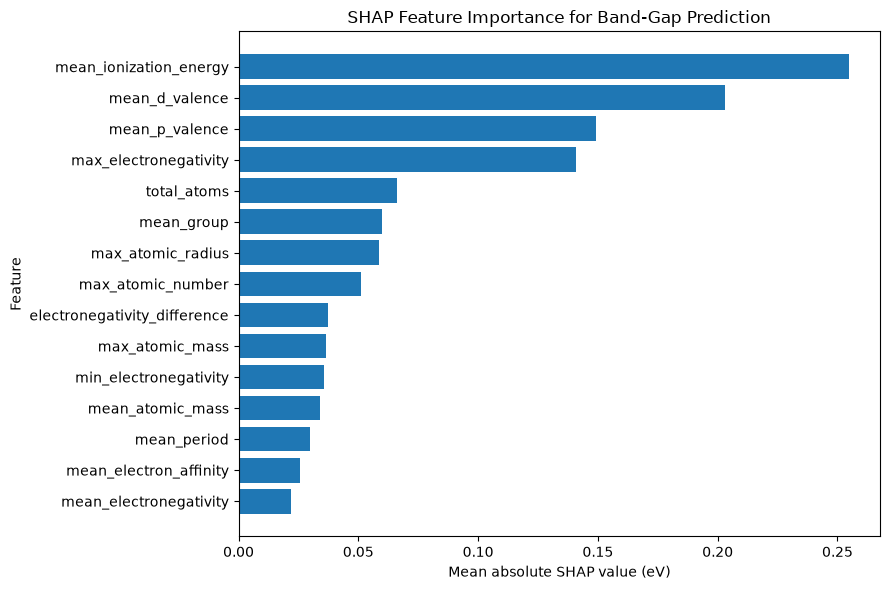

SHAP figure saved successfully.
File: F:\Quantum-materials\figures\shap_feature_importance.png


In [4]:


import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path(r"F:\Quantum-materials")
RESULTS = ROOT / "results"
FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

# Load SHAP results
shap_file = RESULTS / "shap_feature_importance.csv"
shap_df = pd.read_csv(shap_file)

# Clean feature names
shap_df["feature"] = (
    shap_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort by SHAP importance
shap_df = shap_df.sort_values(
    "mean_abs_shap",
    ascending=False
)

# Select top 15
top_shap = shap_df.head(15).sort_values(
    "mean_abs_shap",
    ascending=True
)

# Plot
plt.figure(figsize=(9, 6))

plt.barh(
    top_shap["feature"],
    top_shap["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value (eV)")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance for Band-Gap Prediction")

plt.tight_layout()

# Save high-resolution figure
output_file = FIGURES / "shap_feature_importance.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP figure saved successfully.")
print("File:", output_file)

## 7. Save a trustworthiness summary

The outputs from this notebook can be used by the Streamlit application later: prediction, uncertainty proxy, conformal interval, and applicability-domain score.


In [6]:
# Cell 34 — Save Trustworthiness Summary

import json
from pathlib import Path

ROOT = Path(r"F:\Quantum-materials")
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

trustworthiness_summary = {
    "model": {
        "name": "Random Forest Regressor",
        "task": "OptB88vdW band-gap prediction",
        "n_materials": 93902,
        "n_features": 25
    },

    "test_performance": {
        "mae_eV": 0.2381,
        "rmse_eV": 0.5559,
        "r2": 0.8195
    },

    "uncertainty_analysis": {
        "method": "Random Forest tree prediction dispersion",
        "note": "Uncertainty proxy, not a calibrated prediction interval",
        "mean_absolute_error": 0.238135,
        "mean_error_by_uncertainty_group": {
            "low": 0.007484,
            "medium": 0.170010,
            "high": 0.767611
        }
    },

    "conformal_prediction": {
        "method": "Split conformal prediction",
        "nominal_coverage": 0.90,
        "observed_test_coverage": 0.8992,
        "interval_half_width_eV": 0.7849,
        "interval_width_eV": 1.5698
    },

    "applicability_domain": {
        "method": "5-nearest-neighbor distance in standardized descriptor space",
        "note": "Applicability-domain proxy, not a universal OOD detector",
        "mae_by_distance_group": {
            "low": 0.198895,
            "medium_low": 0.186364,
            "medium_high": 0.237960,
            "high": 0.329328
        }
    },

    "chemical_system_validation": {
        "method": "GroupKFold by chemical system",
        "mae_eV": 0.3109,
        "mae_std_eV": 0.0113,
        "rmse_eV": 0.6773,
        "rmse_std_eV": 0.0380,
        "r2": 0.7324,
        "r2_std": 0.0156,
        "overlapping_groups": 0
    },

    "interpretability": {
        "method": "Permutation importance",
        "n_repeats": 5,
        "top_features": [
            {
                "feature": "mean_ionization_energy",
                "importance": 0.282553
            },
            {
                "feature": "mean_d_valence",
                "importance": 0.244844
            },
            {
                "feature": "mean_p_valence",
                "importance": 0.242303
            },
            {
                "feature": "mean_group",
                "importance": 0.114578
            },
            {
                "feature": "max_electronegativity",
                "importance": 0.110624
            },
            {
                "feature": "total_atoms",
                "importance": 0.094639
            }
        ],

        "shap": {
            "method": "TreeSHAP",
            "sample_size": 200,
            "top_features": [
                {
                    "feature": "mean_ionization_energy",
                    "mean_abs_shap": 0.254998
                },
                {
                    "feature": "mean_d_valence",
                    "mean_abs_shap": 0.203180
                },
                {
                    "feature": "mean_p_valence",
                    "mean_abs_shap": 0.149164
                },
                {
                    "feature": "max_electronegativity",
                    "mean_abs_shap": 0.140682
                },
                {
                    "feature": "total_atoms",
                    "mean_abs_shap": 0.066127
                },
                {
                    "feature": "mean_group",
                    "mean_abs_shap": 0.059815
                }
            ]
        },

        "interpretation_note": (
            "Feature importance indicates predictive usefulness within the model "
            "and should not be interpreted as causal evidence."
        )
    },

    "overall_assessment": {
        "random_split_performance": "strong predictive performance",
        "chemical_system_generalization": "performance decreases when chemically related systems are held out",
        "uncertainty": "higher uncertainty is associated with larger prediction errors",
        "conformal_prediction": "empirical coverage is close to the nominal 90% target",
        "applicability_domain": "larger descriptor-space distance is associated with higher error",
        "interpretability": "permutation importance and SHAP identify consistent leading descriptors"
    }
}

output_file = RESULTS / "advanced_trustworthiness_summary.json"

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(trustworthiness_summary, f, indent=2)

print("Trustworthiness summary saved successfully.")
print("File:", output_file)

Trustworthiness summary saved successfully.
File: F:\Quantum-materials\results\advanced_trustworthiness_summary.json
